<a href="https://colab.research.google.com/github/MuzammilBughio/Machine-Learning-Practice-and-Projects-/blob/main/Shop_EcommercePracticeProjectDTClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/shop_ecommerce.csv")

In [3]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [5]:
df.isnull().sum()

,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


In [6]:
df.apply(lambda col : col.unique())


,0
Administrative,"[0, 1, 2, 4, 12, 3, 10, 6, 5, 9, 8, 16, 13, 11..."
Administrative_Duration,"[0.0, 53.0, 64.6, 6.0, 18.0, 9.0, 56.0, 16.0, ..."
Informational,"[0, 1, 2, 4, 16, 5, 3, 14, 6, 12, 7, 9, 10, 8,..."
Informational_Duration,"[0.0, 120.0, 16.0, 94.0, 93.0, 75.0, 19.0, 22...."
ProductRelated,"[1, 2, 10, 19, 0, 3, 16, 7, 6, 23, 13, 20, 8, ..."
ProductRelated_Duration,"[0.0, 64.0, 2.666666667, 627.5, 154.2166667, 3..."
BounceRates,"[0.2, 0.0, 0.05, 0.02, 0.015789474, 0.01875, 0..."
ExitRates,"[0.2, 0.1, 0.14, 0.05, 0.024561404, 0.02222222..."
PageValues,"[0.0, 54.17976426, 19.44707913, 38.30849268, 2..."
SpecialDay,"[0.0, 0.4, 0.8, 1.0, 0.2, 0.6]"


EDA


In [ ]:
num_cols = df.select_dtypes(include = 'number')
corr_matrix = num_cols.corr()
plt.figure(figsize = (15 , 8))
sns.heatmap(corr_matrix , annot=True , fmt = '.2f' , cmap = 'coolwarm')

In [8]:
# convert target values into numerical values
df['Revenue'] = df['Revenue'].astype(int)


In [9]:
X = df.drop('Revenue' , axis =1)
y= df['Revenue']

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

Without GridSearchCV and any hyperparameters

In [64]:
continuous_cols = ['Administrative' , 'Administrative_Duration' , 'Informational' , 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration' , 'BounceRates' , 'ExitRates' , 'PageValues' ]
ordinal_cols = ['SpecialDay' , 'OperatingSystems' , 'Region' , 'TrafficType']
onehot_cols = ['VisitorType', 'Month','Weekend']


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), continuous_cols),
        ('cat_onehot', OneHotEncoder(handle_unknown='ignore'), onehot_cols),
        ('cat_ordinal', OrdinalEncoder(), ordinal_cols)
    ],
    remainder='drop'
)

# Pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42))
])


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42 ,stratify=y )

pipeline.fit(X_train, y_train)

accuracy = pipeline.score(X_test, y_test)
predictions = pipeline.predict(X_test)

print(f"Model Accuracy: {accuracy}")

from sklearn.metrics import f1_score
print("f1 score ",f1_score(y_test , predictions ))


Model Accuracy: 0.8609083536090836
f1 score  0.5516339869281046


In [53]:
default_tree = pipeline.named_steps['model']

print(default_tree.get_params())

{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}


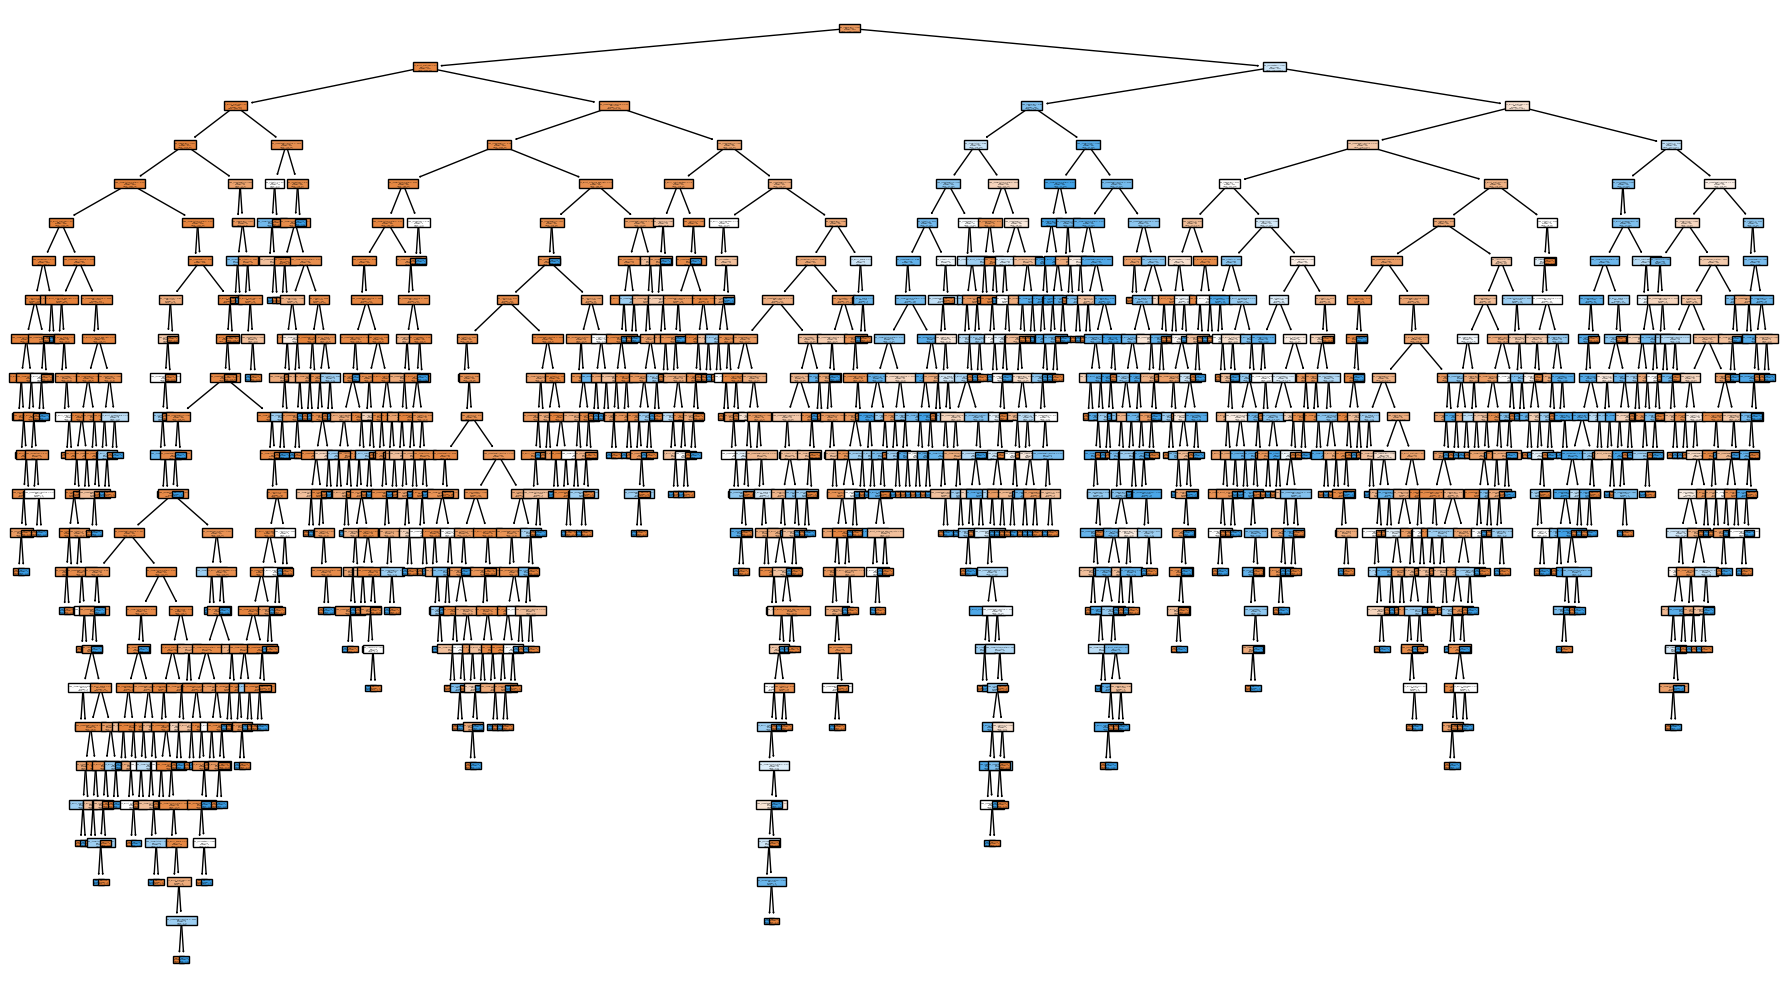

In [28]:
from sklearn.tree import plot_tree

trained_tree = pipeline.named_steps['model']
preprocessed_features = pipeline.named_steps['preprocessor'].get_feature_names_out()


plt.figure(figsize =(18 , 10))
plot_tree(trained_tree,
          feature_names=preprocessed_features,
          filled=True ,
          class_names = ['False' , 'True']

)
plt.tight_layout()
plt.show()

With GridSearchCV and any hyperparameters

In [78]:
continuous_cols = ['Administrative' , 'Administrative_Duration' , 'Informational' , 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration' , 'BounceRates' , 'ExitRates' , 'PageValues' ]
ordinal_cols = ['SpecialDay' , 'OperatingSystems' , 'Region' , 'TrafficType']
onehot_cols = ['VisitorType', 'Month','Weekend']


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), continuous_cols),
        ('cat_onehot', OneHotEncoder(handle_unknown='ignore'), onehot_cols),
        ('cat_ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ordinal_cols)
    ],
    remainder='drop'
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42))
])

param_grid = {
    "model__max_depth" : [3, 5, 10, 20, 30, None],
    "model__min_samples_split" : [2 , 4 , 8 , 16 , 30]
}

modelGridCV = GridSearchCV(pipeline , param_grid , cv =5 , scoring ='accuracy')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42 ,stratify=y )

modelGridCV.fit(X_train, y_train)

accuracy = modelGridCV.score(X_test, y_test)
predictions = modelGridCV.predict(X_test)

print(f"Model Accuracy: {accuracy}")


Model Accuracy: 0.8994322789943228


In [79]:
from sklearn.metrics import f1_score
print(f1_score(y_test , predictions ))

0.6457142857142857


In [80]:
print(modelGridCV.best_params_)

{'model__max_depth': 5, 'model__min_samples_split': 2}


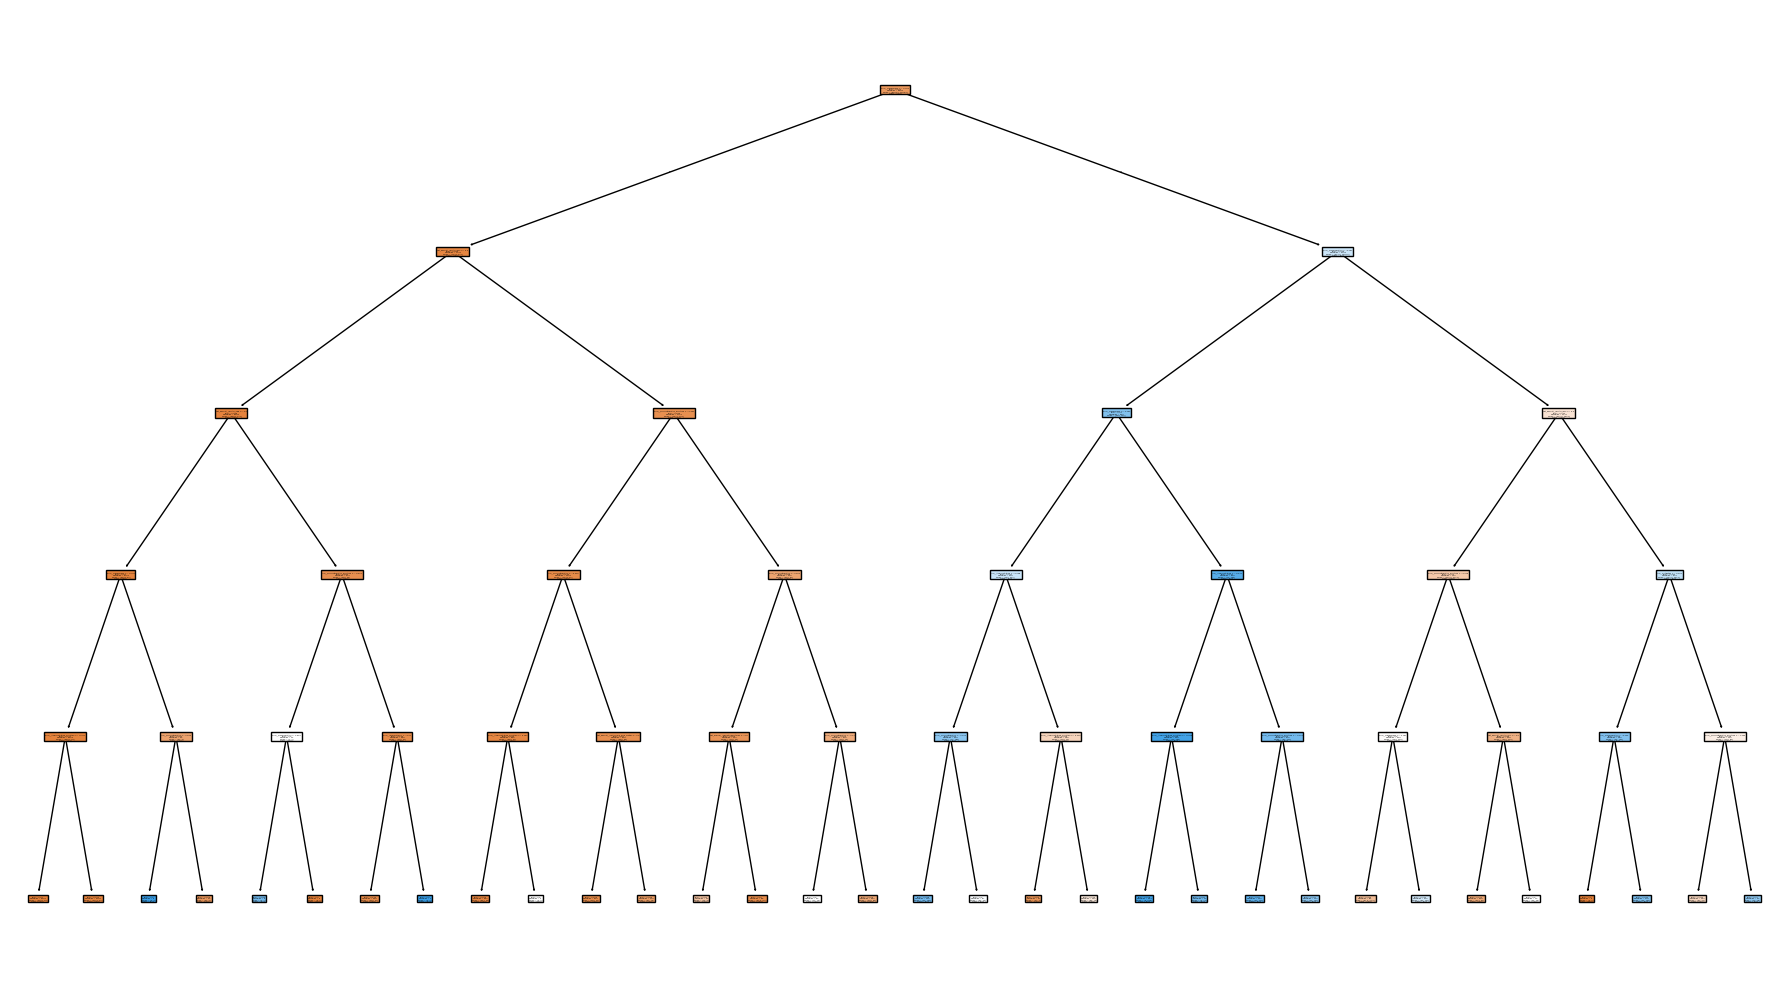

In [81]:
from sklearn.tree import plot_tree

trained_tree =  modelGridCV.best_estimator_.named_steps['model']
preprocessed_features = modelGridCV.best_estimator_.named_steps['preprocessor'].get_feature_names_out()



plt.figure(figsize =(18 , 10))
plot_tree(trained_tree,
          feature_names=preprocessed_features,
          filled=True ,
          class_names = ['False' , 'True']

)
plt.tight_layout()
plt.show()

